In [94]:
import pandas as pd
import numpy as np
from functools import reduce
import seaborn as sns
import yaml

In [95]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

In [96]:
df_cc = pd.read_csv(config['data']['clean']['file1'], quotechar='"', sep = ";")
df_hu = pd.read_csv(config['data']['clean']['file2'], quotechar='"', sep = ";")
df_pp = pd.read_csv(config['data']['clean']['file3'], quotechar='"', sep = ";")
df_qq = pd.read_csv(config['data']['clean']['file4'], quotechar='"', sep = ";")
df_rr = pd.read_csv(config['data']['clean']['file5'], quotechar='"', sep = ";")
df_sd = pd.read_csv(config['data']['clean']['file6'], quotechar='"', sep = ";")
df_ss = pd.read_csv(config['data']['clean']['file7'], quotechar='"', sep = ";")
df_tg = pd.read_csv(config['data']['clean']['file8'], quotechar='"', sep = ";")
df_tn = pd.read_csv(config['data']['clean']['file9'], quotechar='"', sep = ";")
df_tx = pd.read_csv(config['data']['clean']['file10'], quotechar='"', sep = ";")

In [97]:
all_data = reduce(lambda  left,right: pd.merge(left,right,on=['date'],how='outer'), [df_cc,df_hu,df_pp, df_qq,df_rr,df_sd,df_ss,df_tg,df_tn,df_tx])

In [98]:
df_ad = all_data.drop(columns='date')

<Axes: >

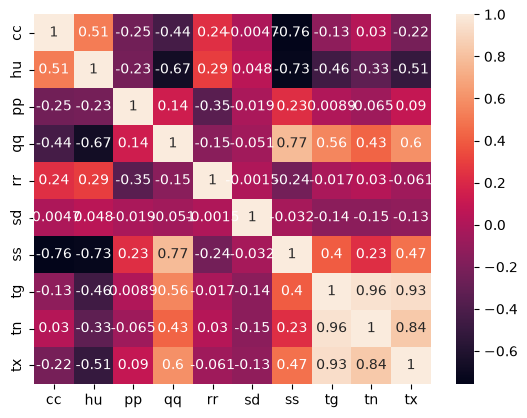

In [99]:
sns.heatmap(df_ad.corr(), annot=True)

In [100]:
df_ad = df_ad.drop(columns=['pp','rr','sd'])

In [101]:
target= df_ad.tx
features = df_ad.drop(columns=['tg','tx','tn'])

In [102]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20,  random_state=0)

In [103]:
X_train.shape
normalizer = MinMaxScaler()
normalizer.fit(X_train)
X_train_norm = normalizer.transform(X_train)
X_test_norm = normalizer.transform(X_test)
X_train_norm = pd.DataFrame(X_train_norm, columns = X_train.columns)
X_test_norm = pd.DataFrame(X_test_norm, columns = X_test.columns)

In [104]:
knn = KNeighborsRegressor()
knn.fit(X_train_norm, y_train)
print(f"The accuracy of the model is {knn.score(X_test_norm, y_test): .2f}")

The accuracy of the model is  0.47


In [105]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor

forest = RandomForestRegressor(n_estimators=100,
                             max_depth=20)
forest.fit(X_train_norm, y_train)
y_pred_test_rf = forest.predict(X_test_norm)


print(f"MAE {mean_absolute_error(y_pred_test, y_test): .2f}") # mean(abs(error)) = mean(abs(y_test - y_pred_test))
print(f"RMSE, {np.sqrt(mean_squared_error(y_pred_test, y_test)): .2f}") # sqrt( mean( (y_test - y_pred_test)^2 ) ) # b0, b1, b2...
print(f"R2 score, {forest.score(X_test_norm, y_test): .2f}")

MAE  3.97
RMSE,  5.03
R2 score,  0.53
